# DISCRETIZATION (Binning)

---> Data preprocessing technique

Discretization means converting continuous numerical values into a small number of groups (bins or intervals).

Instead of working with many different numbers, we group similar values together.

Why do we use Binning?
- Makes data easier to understand.
- Reduces the effect of noise (small variations).
- Some machine learning algorithms work better with categorical values.
- Helps visualize data more clearly.


# Types of Binning

There are three common methods:

1. Uniform Binning
2. Quantile Binning
3. K-Means Binning

---

# 1. Uniform Binning

### Definition

Uniform binning divides the data into **equal-width intervals**.

The width of every bin is the same.

### Example

Suppose the values are

```
10, 20, 30, 40, 50, 60, 70, 80, 90, 100
```

Minimum = 10

Maximum = 100

Suppose we want **3 bins**.

Width of each bin: 100−10/3 ​=30

Bins become:

```
Bin 1 : 10 – 40
Bin 2 : 40 – 70
Bin 3 : 70 – 100
```

Now classify the numbers.

| Value | Bin   |
| ----: | ----- |
|    10 | Bin 1 |
|    20 | Bin 1 |
|    30 | Bin 1 |
|    40 | Bin 1 |
|    50 | Bin 2 |
|    60 | Bin 2 |
|    70 | Bin 2 |
|    80 | Bin 3 |
|    90 | Bin 3 |
|   100 | Bin 3 |

### Picture

```
10--------40--------70--------100
|  Bin1   |  Bin2   |  Bin3   |
```

### Key Idea

* Equal **range (width)**
* Number of data points in each bin may differ.

---

# 2. Quantile Binning

### Definition

Quantile binning divides the data so that **each bin contains approximately the same number of data points**.

The widths of the bins can be different.

### Example

Data:

```
10,20,30,40,50,60,70,80,90,100
```

Suppose we want **2 bins**.

There are 10 numbers.

Each bin gets

```
10 ÷ 2 = 5 values
```

Bins become

```
Bin 1
10,20,30,40,50

Bin 2
60,70,80,90,100
```

Notice:

First bin:

```
10–50
```

Second bin:

```
60–100
```

Each has exactly **5 values**.

### Another Example

Suppose data is

```
1,2,3,4,5,100
```

Using **2 quantile bins**

```
Bin1
1,2,3

Bin2
4,5,100
```

The second bin becomes much wider because of the value 100.

### Key Idea

* Equal **number of observations**
* Bin widths are **not equal**.

---

# 3. K-Means Binning

### Definition

K-Means binning uses the **K-Means clustering algorithm** to group similar values together.

Instead of fixed widths or equal counts, it finds **natural groups** in the data.

### Example

Data:

```
2,3,4,5,50,55,60,100,105
```

If we ask for **3 bins**, K-Means may create:

```
Cluster 1
2,3,4,5

Cluster 2
50,55,60

Cluster 3
100,105
```

Notice the algorithm groups values that are naturally close together.

### Picture

```
2 3 4 5        50 55 60          100 105
|------|        |-------|          |-----|
 Cluster1        Cluster2          Cluster3
```

### Key Idea

* Groups similar values together.
* Bin widths are not fixed.
* Number of items per bin is not fixed.

---

# Comparison Table

| Feature           | Uniform            | Quantile               | K-Means                    |
| ----------------- | ------------------ | ---------------------- | -------------------------- |
| How bins are made | Equal width        | Equal number of values | Natural clusters           |
| Bin width         | Same               | Different              | Different                  |
| Values per bin    | Different          | Same (approximately)   | Different                  |
| Based on          | Range              | Ranking                | Distance between values    |
| Best for          | Evenly spread data | Balanced groups        | Data with natural clusters |

---

# Real-Life Example (Age)

Suppose ages are

```
18,20,22,25,30,35,40,65,70,75
```

### Uniform (3 bins)

```
18–37
38–56
57–75
```

### Quantile (3 bins)

Each bin gets about **3–4 people**:

```
18,20,22
25,30,35
40,65,70,75
```

### K-Means

Natural groups:

```
Young:
18,20,22,25

Adults:
30,35,40

Senior:
65,70,75
```

* **Uniform** → **Equal Width** (same-sized intervals)
* **Quantile** → **Equal Count** (same number of data points)
* **K-Means** → **Equal Similarity** (groups similar values together)

A simple analogy is sorting books:

* **Uniform:** Divide a shelf into equal-length sections.
* **Quantile:** Put the same number of books on each shelf.
* **K-Means:** Group books by similar topics, even if each group has a different number of books or takes up different shelf space.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
df = sns.load_dataset('titanic')
df = df[['age', 'fare', 'survived']]
df.head()

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [3]:
df.dropna(inplace=True)

In [4]:
df.shape

(714, 3)

In [5]:
X = df[['age', 'fare']]
y = df['survived']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [7]:
X_train.head(2)

,age,fare
328,31.0,20.5250
73,26.0,14.4542


In [8]:
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.6223776223776224

In [9]:
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy'))

np.float64(0.6303403755868545)

In [10]:
# Applying Binning (Discretization) on data -- Quantile
kbin_age = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')

In [11]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [12]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.fit_transform(X_test)

In [13]:
print(trf.named_transformers_['first'].n_bins_)
print(trf.named_transformers_['second'].n_bins_)

[10]
[10]


In [14]:
print(trf.named_transformers_['first'].bin_edges_)
print(trf.named_transformers_['second'].bin_edges_)

[array([ 1., 11., 17., 20., 24., 28., 30., 35., 39., 48., 62.])]
[array([  0.    ,   7.7417,   7.925 ,   8.6625,  10.5   ,  14.4542,
         22.525 ,  29.125 ,  39.    ,  57.9792, 512.3292])         ]


In [15]:
output = pd.DataFrame({
    'age': X_train['age'],
    'age_trf': X_train_trf[:,0],
    'fare': X_train['fare'],
    'fare_trf': X_train_trf[:,1]
})

In [16]:
output['age_labels'] = pd.cut(x=X_train['age'],
                              bins=trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels'] = pd.cut(x=X_train['fare'],
                              bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [17]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
210,24.0,3.0,7.05,0.0,"(20.0, 24.0]","(0.0, 7.742]"
308,30.0,5.0,24.00,5.0,"(28.0, 30.0]","(22.525, 29.125]"
706,45.0,8.0,13.50,4.0,"(39.0, 48.0]","(10.5, 14.454]"
726,30.0,5.0,21.00,5.0,"(28.0, 30.0]","(14.454, 22.525]"
655,24.0,3.0,73.50,8.0,"(20.0, 24.0]","(57.979, 512.329]"


In [18]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred2 = clf.predict(X_test_trf)
accuracy_score(y_test, y_pred2)

0.6853146853146853

In [19]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy'))

np.float64(0.6302425665101721)

In [20]:
def discretize(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy')))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(X['age'], kde=True)
    plt.title('age before Plot')

    plt.subplot(1, 2, 2)
    sns.histplot(X_trf[:,0], kde=True, color='red')
    plt.title('age after Plot')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(X['fare'], kde=True)
    plt.title('fare before Plot')

    plt.subplot(1, 2, 2)
    sns.histplot(X_trf[:,1], kde=True, color='red')
    plt.title('fare after Plot')

    plt.tight_layout()
    plt.show()

findfont: Failed to find font weight normal, now using 700.


0.6358959311424099


findfont: Failed to find font weight normal, now using 700.


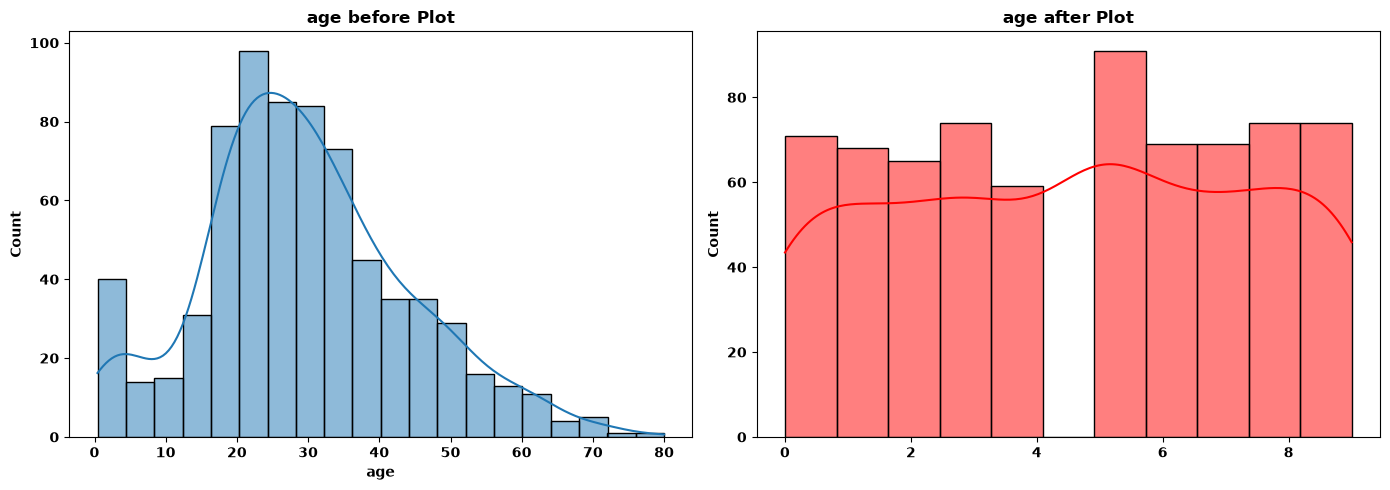

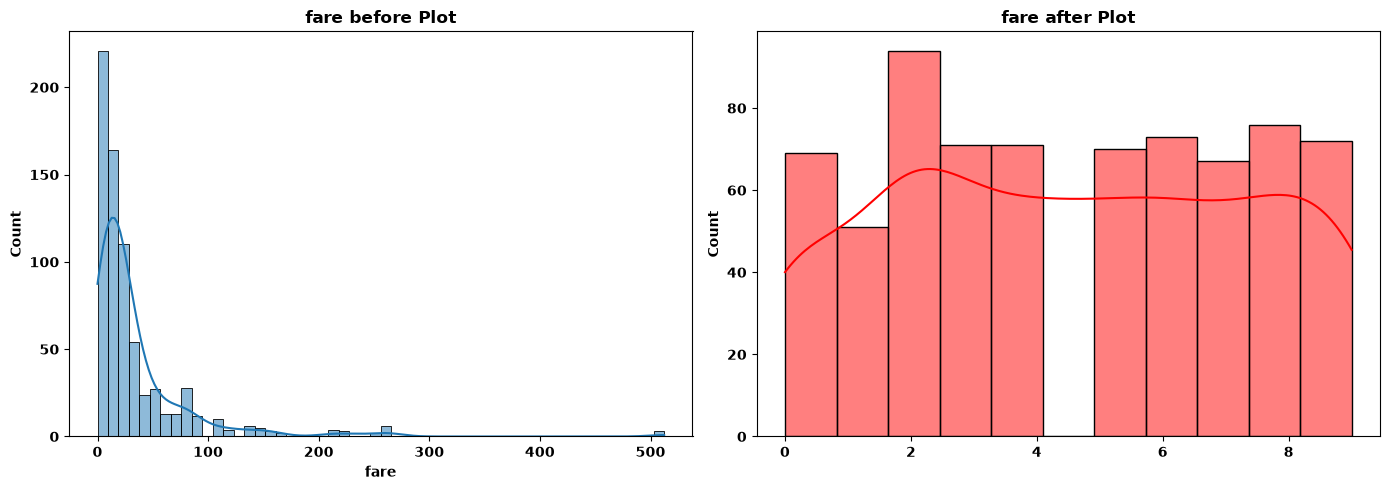

In [21]:
discretize(10, 'quantile')

0.6330790297339592


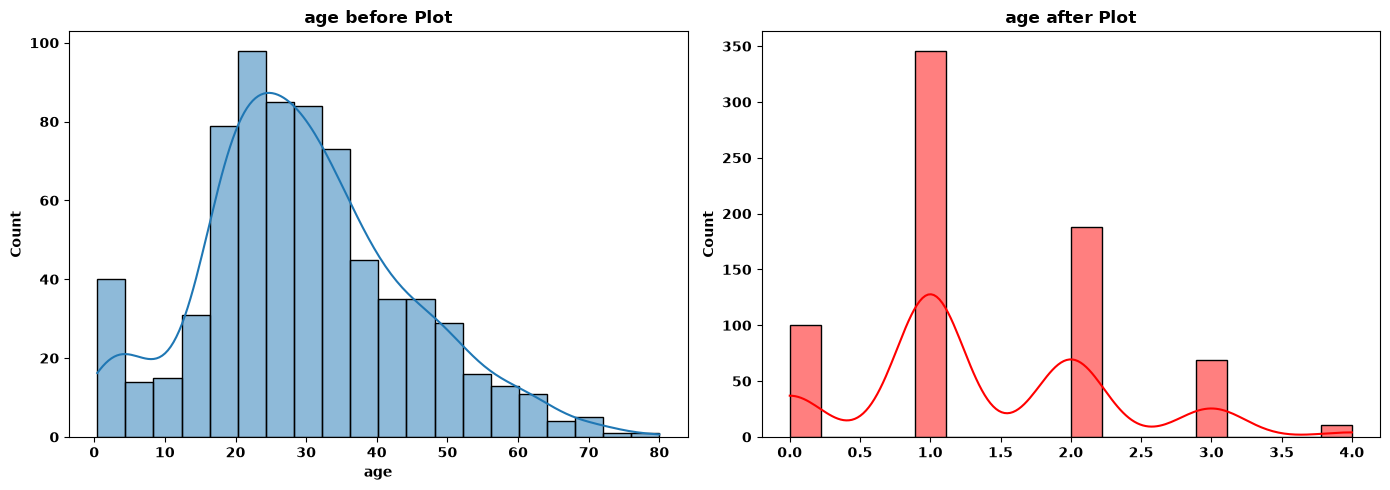

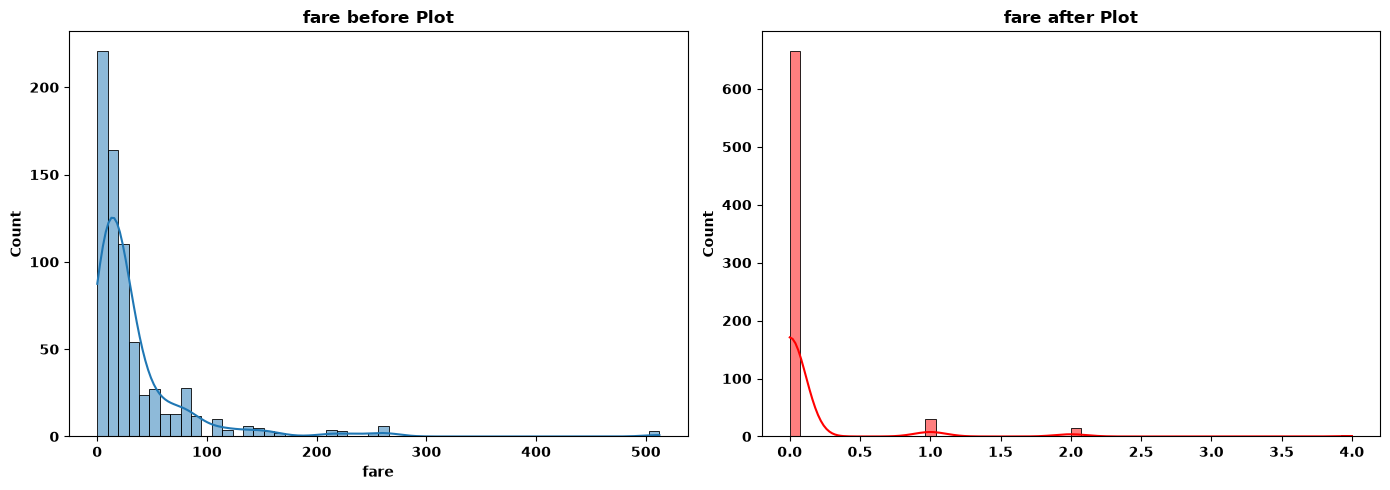

In [22]:
discretize(5, 'uniform')

0.6330594679186229


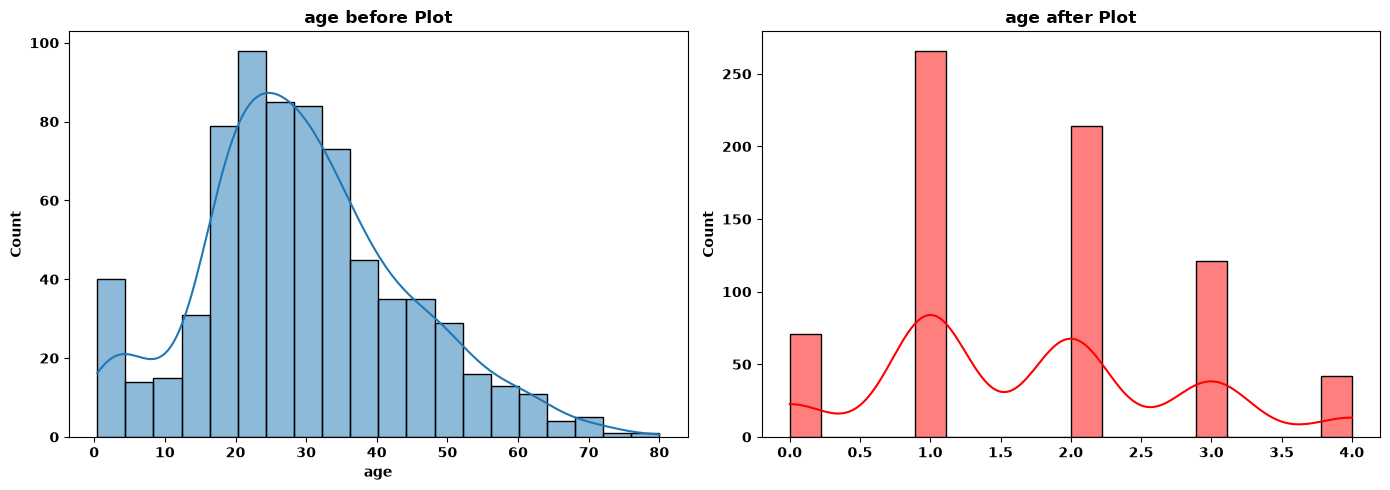

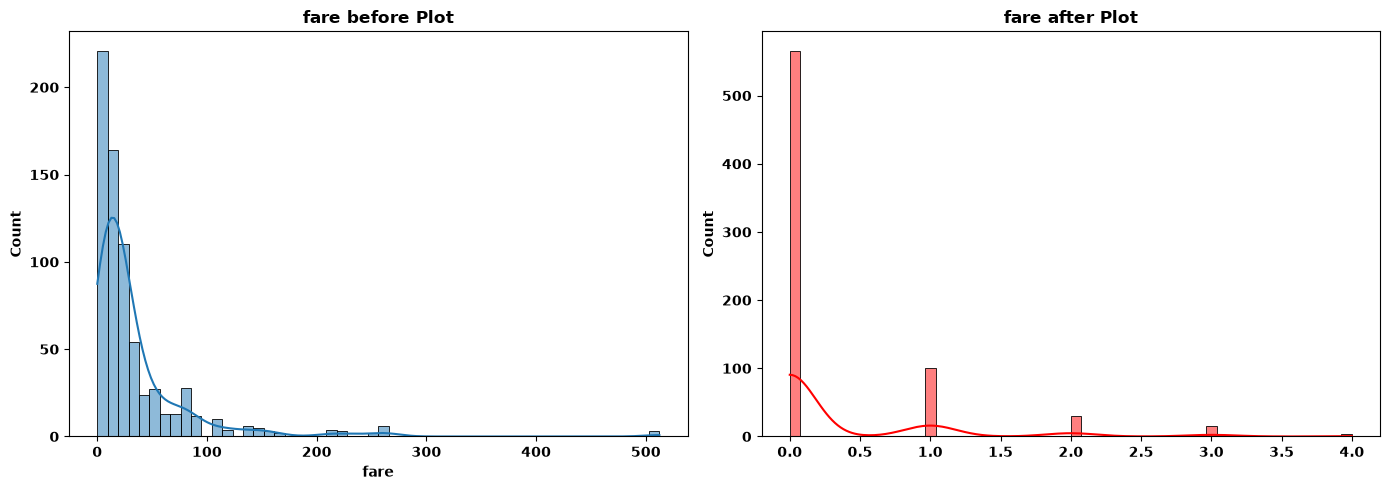

In [23]:
discretize(5, 'kmeans')